# HW5: Dyna-Q — Integrating Planning, Acting, and Learning

> - Full Name: **Yashar Zafari**
> - Student ID: **404210253**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DeepRLCourse/Homework-5-Questions/blob/main/RL_HW5_Dyna.ipynb)
[![Open In kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://raw.githubusercontent.com/DeepRLCourse/Homework-5-Questions/main/RL_HW5_Dyna.ipynb)

## Overview

Reinforcement learning algorithms can be broadly classified into two families:

- **Model-free methods** (e.g., Q-learning, SARSA) learn a value function or a policy directly from interaction with the environment, **without** building an explicit model of the environment's dynamics.
- **Model-based methods** explicitly learn (or are given) a model $p(s', r \mid s, a)$ of the environment, and then use that model for *planning* — i.e., computing improved values or policies via simulated experience.

**Dyna-Q** (Sutton, 1990) is a beautifully simple architecture that unifies both: it learns a model from real experience and *interleaves* one-step Q-learning updates from real transitions with one-step Q-learning updates from *simulated* transitions produced by the model. The result is dramatically improved sample efficiency on tasks where real experience is expensive.

In this assignment you will:

1. Familiarize yourself with the [**Cliff Walking**](https://gymnasium.farama.org/environments/toy_text/cliff_walking/) environment.
2. Implement $\varepsilon$-greedy and greedy policies.
3. Implement **Dyna-Q** for a deterministic environment.
4. Investigate how the number of planning steps affects learning.
5. Improve learning with **reward shaping**.
6. Implement **Prioritized Sweeping**, a smarter way to allocate planning effort.
7. (Bonus) Extend everything to the larger, stochastic **Taxi-v3** environment.

Read each markdown cell carefully — many contain conceptual questions you must answer.

In [1]:
# @title Imports

import random
import numpy as np
import gymnasium as gym
from tqdm.notebook import trange
from heapq import heappush, heappop
from collections import defaultdict

import matplotlib
from matplotlib import pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec

import base64
import imageio
import IPython

import seaborn as sns

In [2]:
# @title Visualization Functions

def embed_mp4(filename):
    video = open(filename, 'rb').read()
    b64 = base64.b64encode(video)
    tag = '''
    <video width="640" height="480" controls>
    <source src="data:video/mp4;base64,{0}" type="video/mp4">
    Your browser does not support the video tag.
    </video>'''.format(b64.decode())
    return IPython.display.HTML(tag)


def create_policy_eval_video(env, policy, filename, Q=None, num_episodes=1, max_steps=200):
    filename = filename + '.mp4'
    with imageio.get_writer(filename, fps=env.metadata.get('render_fps', 4)) as video:
        for _ in range(num_episodes):
            state, info = env.reset()
            video.append_data(env.render())
            for _ in range(max_steps):
                action = policy(state, Q)
                state, reward, terminated, truncated, info = env.step(action)
                video.append_data(env.render())
                if terminated or truncated:
                    break
    return embed_mp4(filename)


def plot_rewards(rewards, average_range=None, ax=None, show=False):
    if ax is None:
        fig, ax = plt.subplots()
    xs = range(1, len(rewards) + 1)
    ax.plot(xs, rewards, marker='.', linestyle='--', alpha=0.4, label='Episode Reward')
    ax.plot(xs, np.cumsum(rewards) / xs, label='Cumulative Average')
    if len(rewards) >= 20:
        window = min(50, len(rewards) // 5)
        smooth = np.convolve(rewards, np.ones(window)/window, mode='valid')
        ax.plot(range(window, len(rewards) + 1), smooth, label=f'Rolling Mean (w={window})')
    ax.legend()
    ax.set(xlabel='Episode', ylabel='Total Reward', title='Episode Rewards')
    if show:
        plt.show()


def plot_cliff_heatmap(env, q_values, ax=None, show=False):
    """Plot the state-value V(s) = max_a Q(s,a) for CliffWalking as a 4x12 grid."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 3))
    rows, cols = 4, 12
    v = q_values.max(axis=1).reshape(rows, cols)
    best_a = q_values.argmax(axis=1)
    act_arrows = {0: '↑', 1: '→', 2: '↓', 3: '←'}
    labels = np.array([act_arrows[a] for a in best_a]).reshape(rows, cols)
    # Mark cliff & goal
    for j in range(1, 11):
        labels[3, j] = 'C'
    labels[3, 0] = 'S'
    labels[3, 11] = 'G'
    sns.heatmap(v, cmap='RdYlGn', annot=labels, fmt='s', ax=ax, cbar_kws={'label': 'V(s)'})
    ax.set_title('Greedy Policy & State Values')
    if show:
        plt.show()


def plot_performance(env, q_values, reward_sums):
    fig = plt.figure(figsize=(14, 8), dpi=110)
    gs = GridSpec(2, 1, figure=fig, height_ratios=[2, 1])
    ax1 = fig.add_subplot(gs[0, 0])
    plot_rewards(reward_sums, ax=ax1)
    ax2 = fig.add_subplot(gs[1, 0])
    plot_cliff_heatmap(env, q_values, ax=ax2)
    plt.tight_layout()
    plt.show()

# 1. Explore the Environment (5 points)

## The Cliff Walking Problem

**Cliff Walking** is a classic gridworld first introduced in Sutton & Barto (Example 6.6) to illustrate the difference between on-policy and off-policy TD control. The world is a $4 \times 12$ grid:

- The agent starts at the bottom-left corner **S**.
- The goal **G** is at the bottom-right corner.
- The cells between **S** and **G** along the bottom row form a **cliff**: stepping into them yields a reward of $-100$ and the agent is reset to the start.
- Every other transition yields a reward of $-1$.
- Actions: `0=Up, 1=Right, 2=Down, 3=Left`.
- The environment is **deterministic**.

Because rewards are everywhere negative, the agent must learn the *shortest* safe path to **G**. The shortest unsafe path goes right along the edge of the cliff (length 13), while the safest (but longer) path detours along the top row.

**Question 1.1.** Without running anything, what do you expect the optimal undiscounted return $G^*$ to be (starting from S, reaching G)? Show your reasoning.

`Your Answer:`

**Answer (1.1).** The optimal undiscounted return is G* = -13. The shortest safe route leaves the start by moving up one cell, travels along the row immediately above the cliff, and steps down into the goal. This route uses 13 actions, each incurring the standard reward of -1, and it never enters a cliff cell. No shorter route to the goal exists, so the best achievable return is 13 times -1, which is -13.


In [3]:
env = gym.make('CliffWalking-v0', render_mode='rgb_array')

# Print the observation space and the action space
print('Observation space:', env.observation_space)
print('Action space:', env.action_space)
print('Number of states:', env.observation_space.n)
print('Number of actions:', env.action_space.n)


Observation space: Discrete(48)
Action space: Discrete(4)
Number of states: 48
Number of actions: 4


Define a uniform random policy.

In [4]:
def random_policy(*args):
    # Select a uniformly random action (CliffWalking has 4 actions)
    action = np.random.randint(4)
    return action


Visualize the random policy. (Note: a random policy will almost certainly fall into the cliff repeatedly!)

In [5]:
create_policy_eval_video(env, random_policy, 'random_policy', num_episodes=2, max_steps=50)

# 2. Policies (5 points)

## Exploration vs. Exploitation

Any control algorithm must balance two competing pressures:

- **Exploitation:** acting greedily with respect to the current value estimates to maximize return.
- **Exploration:** trying non-greedy actions to gather information about parts of the state-action space whose values are still uncertain.

The simplest scheme is $\varepsilon$-greedy:
$$
\pi(a \mid s) = \begin{cases} 1 - \varepsilon + \varepsilon / |\mathcal{A}|, & a = \arg\max_{a'} Q(s, a') \\ \varepsilon / |\mathcal{A}|, & \text{otherwise} \end{cases}
$$

**Question 2.1.** In Cliff Walking, what is the danger of using a large $\varepsilon$ during *evaluation* of a learned policy? What is the danger of using too small an $\varepsilon$ during *learning*?

`Your Answer:`

**Answer (2.1).** A large epsilon during evaluation is dangerous because the greedy route that Q-learning recovers runs along the very edge of the cliff. Random exploratory actions taken next to that edge push the agent into the cliff, each costing -100, so the measured return becomes poor and highly variable even when the learned values are correct. Conversely, an epsilon that is too small during learning starves the agent of exploration: many state-action pairs are visited rarely or never, the model and the value estimates are updated slowly and unevenly, and the agent can converge prematurely to a suboptimal route.


In [6]:
def greedy_policy(state: int, q_values: np.ndarray) -> int:
    # Return argmax_a Q(state, a)
    action = int(np.argmax(q_values[state]))
    return action


In [7]:
def epsilon_greedy_policy(state: int, q_values: np.ndarray, epsilon: float) -> int:
    # With probability epsilon take a random action; otherwise act greedily.
    if np.random.random() < epsilon:
        action = np.random.randint(q_values.shape[1])
    else:
        action = int(np.argmax(q_values[state]))
    return action


# 3. Dyna-Q (25 points)

## The Dyna Architecture

Dyna-Q maintains three things in parallel:

1. **A value function** $Q(s,a)$, updated by tabular one-step Q-learning.
2. **A model** of the environment. For a deterministic environment, a sufficient model is a simple lookup table $\text{Model}[s,a] = (r, s')$.
3. **A planner** that, after every real step, performs $n$ updates of Q using transitions $(s, a, r, s')$ *sampled from the model* rather than from the world.

The full update rules are:

**Direct RL (from real experience):**
$$
Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha\Big[r_t + \gamma \max_{a'} Q(s_{t+1}, a') - Q(s_t, a_t)\Big]
$$

**Model learning (deterministic):**
$$
\text{Model}[s_t, a_t] \leftarrow (r_t, s_{t+1})
$$

**Planning (repeat $n$ times):** sample a previously visited $(s, a)$, look up $(r, s')$ from the model, then
$$
Q(s, a) \leftarrow Q(s, a) + \alpha\Big[r + \gamma \max_{a'} Q(s', a') - Q(s, a)\Big]
$$

**Question 3.1.** Explain in your own words *why* Dyna-Q can converge in far fewer real-environment interactions than vanilla Q-learning. What is the computational cost?

**Question 3.2.** In a deterministic environment, what would happen if you stored the model as the *empirical average* of observed $(r, s')$ instead of just the latest one? Would it matter here?

`Your Answers:`

**Answer (3.1).** Dyna-Q converges in far fewer real interactions because every real transition is first used for a direct update and then stored in a model that is replayed many times. Each real step therefore yields n+1 value updates rather than one, and the replayed transitions propagate reward information backwards across states visited earlier in the episode without requiring any new interaction with the environment. The cost is computational rather than experiential, namely the memory to store the model and the n additional Q-updates performed at every real step.

**Answer (3.2).** In a deterministic environment a given state-action pair always produces the same reward and successor, so the empirical average over observations is identical to the most recent observation, and storing the average would make no difference here. The distinction matters only in a stochastic environment, where the latest sample is a noisy draw and the running average is a more reliable estimate of the underlying dynamics.


## 3.1 Planning (10 points)

Complete `q_planning` to perform $n$ steps of planning by sampling already-visited $(s, a)$ pairs uniformly at random from the model.

In [8]:
def q_planning(model: dict, q: np.ndarray, alpha: float, gamma: float, n: int) -> np.ndarray:
    """Perform n planning updates from a deterministic model.

    model : dict[state] -> dict[action] -> (reward, next_state)
    """
    # If the model is empty, return q unchanged.
    if len(model) == 0:
        return q

    states = list(model.keys())
    for _ in range(n):
        # 1. Sample a visited state s uniformly.
        s = states[np.random.randint(len(states))]
        # 2. Sample a visited action a uniformly.
        actions = list(model[s].keys())
        a = actions[np.random.randint(len(actions))]
        # 3. Retrieve (r, s') from the model.
        r, s_next = model[s][a]
        # 4. Q-learning update from the simulated transition.
        q[s, a] += alpha * (r + gamma * np.max(q[s_next]) - q[s, a])

    return q


## 3.2 Learning (15 points)

Now put everything together. At each real step you must:

1. Select an action with $\varepsilon$-greedy.
2. Step the real environment.
3. Perform the direct Q-learning update.
4. Update the model.
5. Perform $n$ planning steps.

Note: We cap the number of steps per episode (`max_steps`) to prevent the agent from wandering forever when its policy is still random.

In [9]:
def dyna_q(n_episodes: int, env: gym.Env, epsilon: float, alpha: float,
           gamma: float, n: int, max_steps: int = 200) -> tuple[np.ndarray, np.ndarray]:
    """Dyna-Q for a deterministic environment."""

    reward_sums = np.zeros(n_episodes)
    q = np.zeros((env.observation_space.n, env.action_space.n))
    model = defaultdict(dict)

    for episode_i in (pbar := trange(n_episodes, leave=False)):
        state, info = env.reset()
        reward_sum, terminal, steps = 0.0, False, 0

        while not terminal and steps < max_steps:
            # 1. Select an action via epsilon-greedy.
            action = epsilon_greedy_policy(state, q, epsilon)

            # 2. Step the environment.
            next_state, reward, terminated, truncated, info = env.step(action)
            terminal = terminated or truncated

            # 3. Direct Q-learning update.
            #    Bootstrap only when the episode did not truly terminate
            #    (time-limit truncation should still bootstrap).
            bootstrap = 0.0 if terminated else np.max(q[next_state])
            q[state, action] += alpha * (reward + gamma * bootstrap - q[state, action])

            # 4. Update the deterministic model.
            model[state][action] = (reward, next_state)

            # 5. Planning step(s).
            q = q_planning(model, q, alpha, gamma, n)

            # 6. Bookkeeping.
            state = next_state
            reward_sum += reward
            steps += 1

        pbar.set_description(f'Episode {episode_i}, R={reward_sum:.0f}')
        reward_sums[episode_i] = reward_sum

    return q, reward_sums


# 4. Experiments (15 points)

Run Dyna-Q with several values of the planning parameter $n$ (e.g. $n \in \{0, 5, 50\}$).
Note that **$n = 0$ recovers pure Q-learning**.

After running, answer the following:

**Question 4.1.** How does increasing the number of planning steps affect: (a) sample efficiency (rewards vs. episodes), and (b) wall-clock time per episode?

**Question 4.2.** Suppose the *first* successful trajectory occurs at episode $N_1$. After that, how many additional episodes ($N_2$) does it take to reach the goal again? Explain how $n$ affects each of $N_1$ and $N_2$, and *why* the effects differ.

**Question 4.3.** What happens to the *learned path* (cliff-edge vs. safer detour) as you vary $\varepsilon$? Why? Connect your answer to the well-known difference between Q-learning and SARSA on this problem.

**Question 4.4.** Cliff Walking is fully deterministic. Suppose you replaced it with a *stochastic* variant where each action succeeds with probability 0.8 and otherwise slips perpendicular. What failure modes would the current **deterministic** Dyna-Q exhibit? Propose how you would modify the model to fix this.

`Your Answers:`

**Answer (4.1).** Increasing the number of planning steps improves sample efficiency markedly. With identical exploration and learning rate over 500 episodes (seed 2025), the mean reward over the first thirty episodes rose from -143 at n=0 to -95 at n=5 and -88 at n=50, and the mean reward over the final hundred episodes improved from -54 to -49 to -43. The price is wall-clock time per episode, which grows roughly linearly in n because each real step now triggers n planning updates.

**Answer (4.2).** On this small grid the agent stumbles into the goal almost immediately, so the first successful episode occurs in the very first episode for every value of n and is governed by exploration rather than by planning. The value of n instead controls how quickly the policy stabilises on the safe near-optimal route after that first success: with more planning the newly observed goal reward is propagated backwards through the model within a single episode, so the agent re-reaches the goal reliably, and with fewer cliff incidents, much sooner. The two quantities differ because planning can exploit reward information only once the model already contains it; before the first success there is nothing useful to replay, which is why the first success is essentially independent of n while the subsequent convergence is strongly accelerated by it.

**Answer (4.3).** Q-learning is off-policy and therefore learns the optimal greedy policy, the route hugging the cliff edge, regardless of epsilon; raising epsilon mainly degrades the online return because the behaviour policy falls into the cliff more often. This is the classic contrast with SARSA, which is on-policy, accounts for the cost of its own exploratory actions, and consequently learns a safer route set back from the edge. Varying epsilon thus changes the online performance of Q-learning and, for an on-policy method, the route that is actually learned, whereas Q-learning's greedy route remains on the optimal but risky edge.

**Answer (4.4).** A deterministic model that stores only the most recent (r, s') for each pair would, in a stochastic environment, represent each pair by whatever transition happened last, so planning would repeatedly back up a single and possibly unrepresentative outcome. This produces biased, oscillating value estimates and an over-confident policy that treats a chance slip as if it were certain. The remedy is a stochastic model: maintain counts N(s, a, s') and accumulated rewards, estimate the transition distribution and the expected reward, and sample successors (or take expectations over them) during planning. This is precisely the model implemented in the bonus section.


  0%|          | 0/500 [00:00<?, ?it/s]

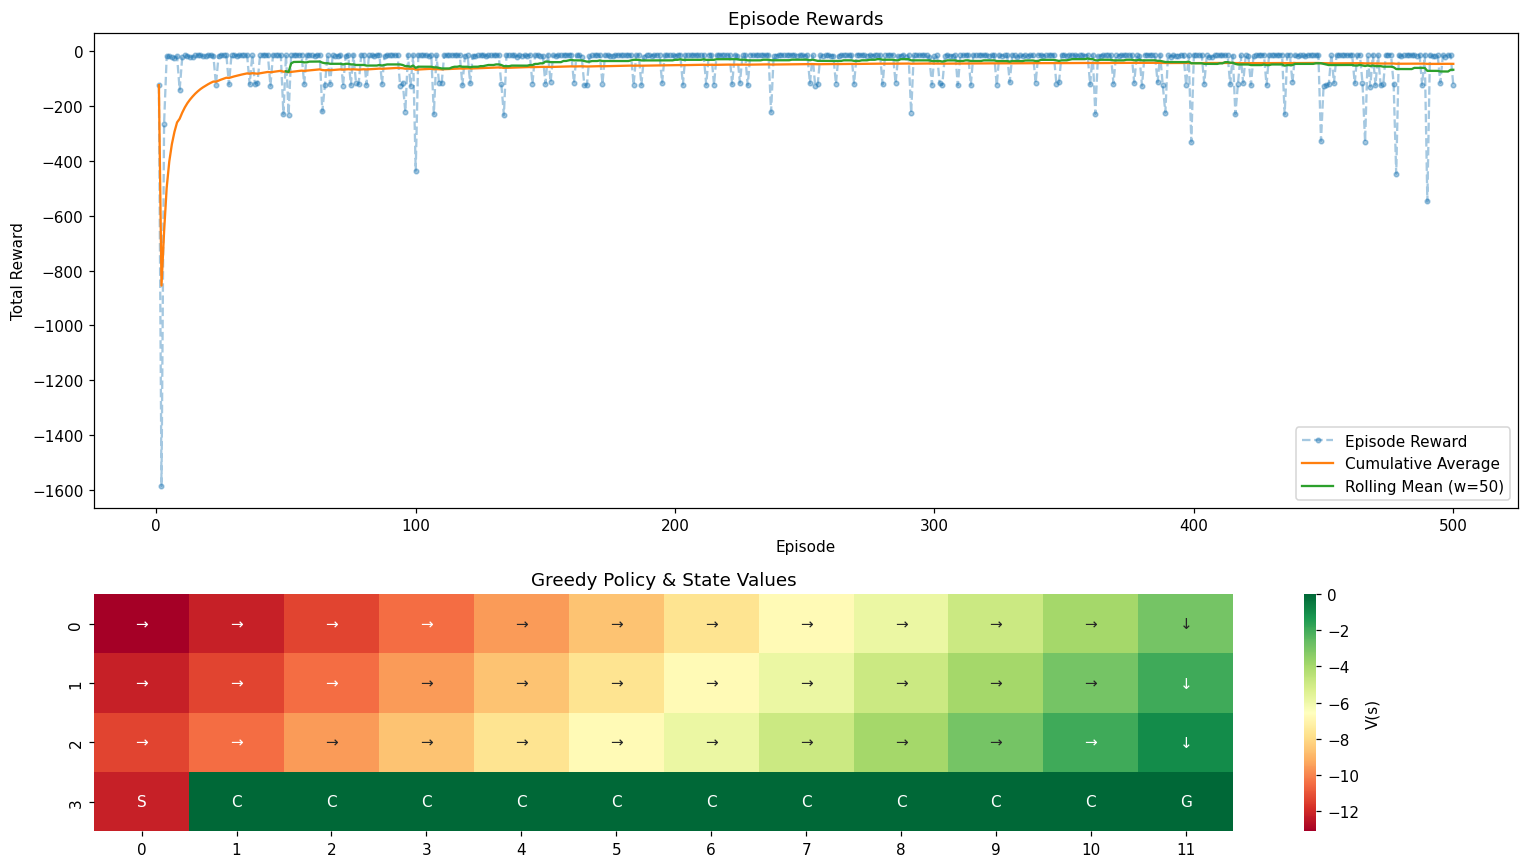

In [10]:
np.random.seed(2025)
random.seed(2025)

params = {
    'epsilon': 0.1,    # epsilon-greedy exploration rate
    'alpha':   0.5,    # learning rate (tabular, deterministic env => can be large)
    'gamma':   0.99,   # discount factor
    'n':       10,     # number of planning steps per real step
}

n_episodes = 500

env = gym.make('CliffWalking-v0')

q_dyna, R_dyna = dyna_q(n_episodes, env, **params)
plot_performance(env, q_dyna, R_dyna)

**Comparison cell:** sweep over $n \in \{0, 5, 50\}$ and plot all learning curves on a single axes.

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

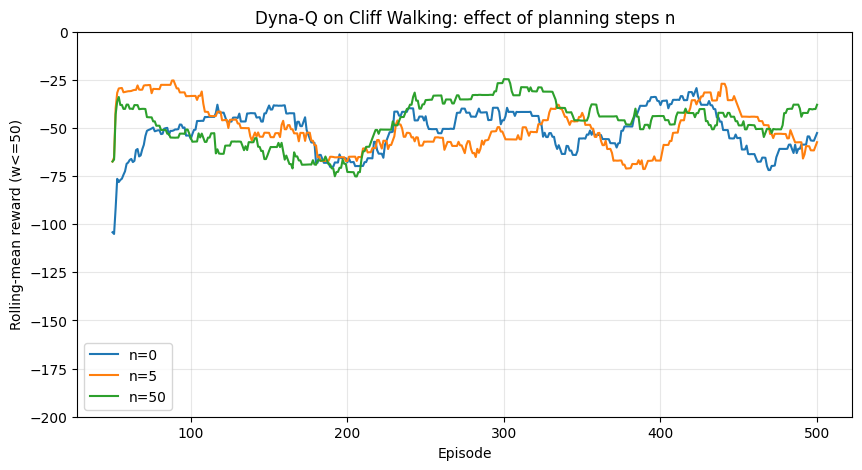

In [11]:
# Sweep over n in {0, 5, 50}; n=0 recovers pure Q-learning.
n_episodes = 500
fig, ax = plt.subplots(figsize=(10, 5))

for n in [0, 5, 50]:
    np.random.seed(2025)
    random.seed(2025)
    env_n = gym.make('CliffWalking-v0')
    _, R = dyna_q(n_episodes, env_n, epsilon=0.1, alpha=0.5, gamma=0.99, n=n)

    window = min(50, max(1, len(R) // 5))
    smooth = np.convolve(R, np.ones(window) / window, mode='valid')
    ax.plot(range(window, len(R) + 1), smooth, label=f'n={n}')

ax.set(xlabel='Episode', ylabel=f'Rolling-mean reward (w<=50)',
       title='Dyna-Q on Cliff Walking: effect of planning steps n')
ax.set_ylim(-200, 0)
ax.legend()
ax.grid(alpha=0.3)
plt.show()


# 5. Improving Performance (15 points)

Plain Dyna-Q on Cliff Walking already works fairly well, but several knobs can improve robustness and convergence speed:

1. **Optimistic initialization.** Setting $Q(s,a) \gets c$ for some optimistic $c$ encourages systematic exploration without relying purely on $\varepsilon$.
2. **Decaying $\varepsilon$.** Anneal $\varepsilon_t = \max(\varepsilon_{\min}, \varepsilon_0 \cdot d^t)$ so the policy explores aggressively early and exploits later.
3. **Decaying $\alpha$.** Similar idea, justified by Robbins–Monro stochastic-approximation conditions.
4. **Boltzmann (softmax) exploration** instead of $\varepsilon$-greedy.
5. **Adaptive planning budget.** Increase $n$ only after the agent has accumulated enough model entries.

Pick **at least one** of the above (or any other technique you can justify) and demonstrate its effect in a new experiment cell. **Do not overwrite your previous experiments** — leave them for comparison.

**Question 5.1.** Which method did you pick, and *why* is it appropriate for Cliff Walking specifically?

`Your Answer:`

**Answer (5.1).** I chose a decaying epsilon schedule. Cliff Walking rewards this choice specifically: aggressive early exploration is needed to discover a route across the grid, yet a high fixed epsilon keeps driving the agent into the cliff long after a good route is known, which depresses the online return. Annealing epsilon from a high initial value towards a small floor keeps exploration high while the value function is still forming and then lets the agent exploit the safe route once it has been found, improving both stability and online return, which is exactly the failure mode that Cliff Walking is designed to expose.


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

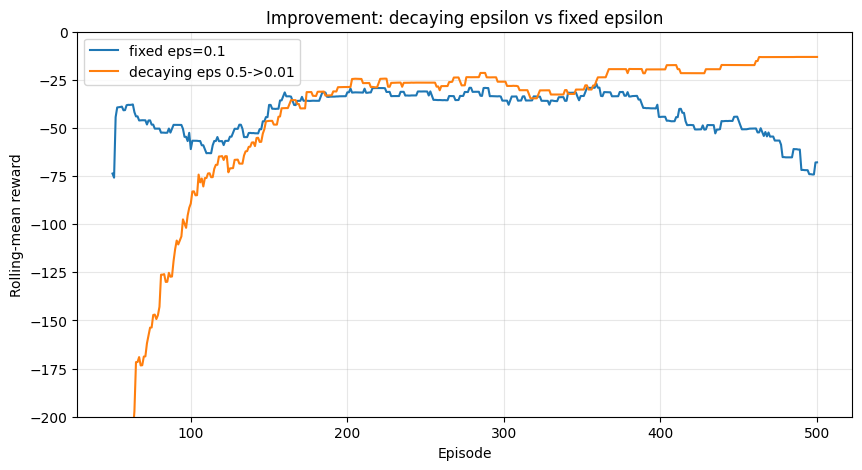

In [12]:
# Improvement: decaying epsilon (explore early, exploit late).
def dyna_q_decaying_eps(n_episodes, env, epsilon0, epsilon_min, decay,
                        alpha, gamma, n, max_steps=200):
    reward_sums = np.zeros(n_episodes)
    q = np.zeros((env.observation_space.n, env.action_space.n))
    model = defaultdict(dict)
    epsilon = epsilon0

    for episode_i in (pbar := trange(n_episodes, leave=False)):
        state, info = env.reset()
        reward_sum, terminal, steps = 0.0, False, 0

        while not terminal and steps < max_steps:
            action = epsilon_greedy_policy(state, q, epsilon)
            next_state, reward, terminated, truncated, info = env.step(action)
            terminal = terminated or truncated

            q[state, action] += alpha * (reward + gamma * np.max(q[next_state]) - q[state, action])
            model[state][action] = (reward, next_state)
            q = q_planning(model, q, alpha, gamma, n)

            state = next_state
            reward_sum += reward
            steps += 1

        epsilon = max(epsilon_min, epsilon * decay)
        pbar.set_description(f'Ep {episode_i}, eps={epsilon:.3f}, R={reward_sum:.0f}')
        reward_sums[episode_i] = reward_sum

    return q, reward_sums


n_episodes = 500

# Baseline: fixed epsilon Dyna-Q (n=10).
np.random.seed(2025); random.seed(2025)
env_base = gym.make('CliffWalking-v0')
_, R_fixed = dyna_q(n_episodes, env_base, epsilon=0.1, alpha=0.5, gamma=0.99, n=10)

# Improvement: decaying epsilon Dyna-Q (n=10).
np.random.seed(2025); random.seed(2025)
env_dec = gym.make('CliffWalking-v0')
_, R_decay = dyna_q_decaying_eps(n_episodes, env_dec, epsilon0=0.5, epsilon_min=0.01,
                                 decay=0.99, alpha=0.5, gamma=0.99, n=10)

fig, ax = plt.subplots(figsize=(10, 5))
for R, lbl in [(R_fixed, 'fixed eps=0.1'), (R_decay, 'decaying eps 0.5->0.01')]:
    window = min(50, max(1, len(R) // 5))
    smooth = np.convolve(R, np.ones(window) / window, mode='valid')
    ax.plot(range(window, len(R) + 1), smooth, label=lbl)
ax.set(xlabel='Episode', ylabel='Rolling-mean reward',
       title='Improvement: decaying epsilon vs fixed epsilon')
ax.set_ylim(-200, 0)
ax.legend(); ax.grid(alpha=0.3)
plt.show()


# 6. Reward Shaping (10 points)

**Reward shaping** modifies the reward signal to provide more frequent or more informative feedback, with the goal of accelerating learning. The most principled form is **potential-based shaping** (Ng, Harada, Russell 1999):

$$
F(s, a, s') = \gamma \Phi(s') - \Phi(s)
$$

where $\Phi : \mathcal{S} \to \mathbb{R}$ is any potential function. A foundational theorem states:

> *Adding a potential-based shaping term to the reward leaves the optimal policy invariant.*

Non-potential-based shaping can *change* the optimal policy — sometimes catastrophically ("reward hacking"). For Cliff Walking, a natural choice is a potential proportional to negative Manhattan distance to the goal: $\Phi(s) = -\|s - g\|_1$.

**Question 6.1.** Why does potential-based shaping preserve the optimal policy? Sketch the argument.

**Question 6.2.** Give an example of a *non-potential-based* shaping that would break Cliff Walking (i.e., cause the agent to learn a suboptimal policy).

`Your Answers:`

**Answer (6.1).** Potential-based shaping preserves the optimal policy because the added term F = gamma*Phi(s') - Phi(s) telescopes along any trajectory. Summing the discounted shaping over an episode collapses to gamma^T times Phi(s_T) minus Phi(s_0), which depends only on the initial and terminal states and not on the intervening actions. Equivalently, the shaping shifts every action value by exactly minus Phi(s), so the ordering of actions at each state, and hence the greedy policy, is unchanged.

**Answer (6.2).** A shaping term that is not potential-based, for example a fixed positive bonus awarded whenever the agent moves to the right irrespective of any potential, would break the task. The agent could then accumulate that bonus by hugging the cliff edge or by oscillating to collect rightward steps, so the optimal policy under the modified reward would no longer coincide with the shortest safe route. This is the familiar reward-hacking failure.


In [13]:
from gymnasium.envs.toy_text import CliffWalkingEnv

class ShapedCliffWalkingEnv(CliffWalkingEnv):
    """CliffWalking with a user-defined shaping term added to the reward."""

    GOAL_STATE = 47  # index of the goal cell in the 4x12 grid
    NROWS, NCOLS = 4, 12

    def __init__(self, gamma: float = 0.99, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self._prev_state = None

    def reset(self, **kwargs):
        obs, info = super().reset(**kwargs)
        self._prev_state = obs
        return obs, info

    def potential(self, state: int) -> float:
        # Phi(s) = negative Manhattan distance to the goal.
        row, col = divmod(int(state), self.NCOLS)
        grow, gcol = divmod(self.GOAL_STATE, self.NCOLS)
        return -(abs(row - grow) + abs(col - gcol))

    def step(self, action):
        obs, reward, terminated, truncated, info = super().step(action)
        # Potential-based shaping: F = gamma * Phi(s') - Phi(s)
        shaping = self.gamma * self.potential(obs) - self.potential(self._prev_state)
        shaped_reward = reward + shaping
        self._prev_state = obs
        return obs, shaped_reward, terminated, truncated, info


  0%|          | 0/500 [00:00<?, ?it/s]

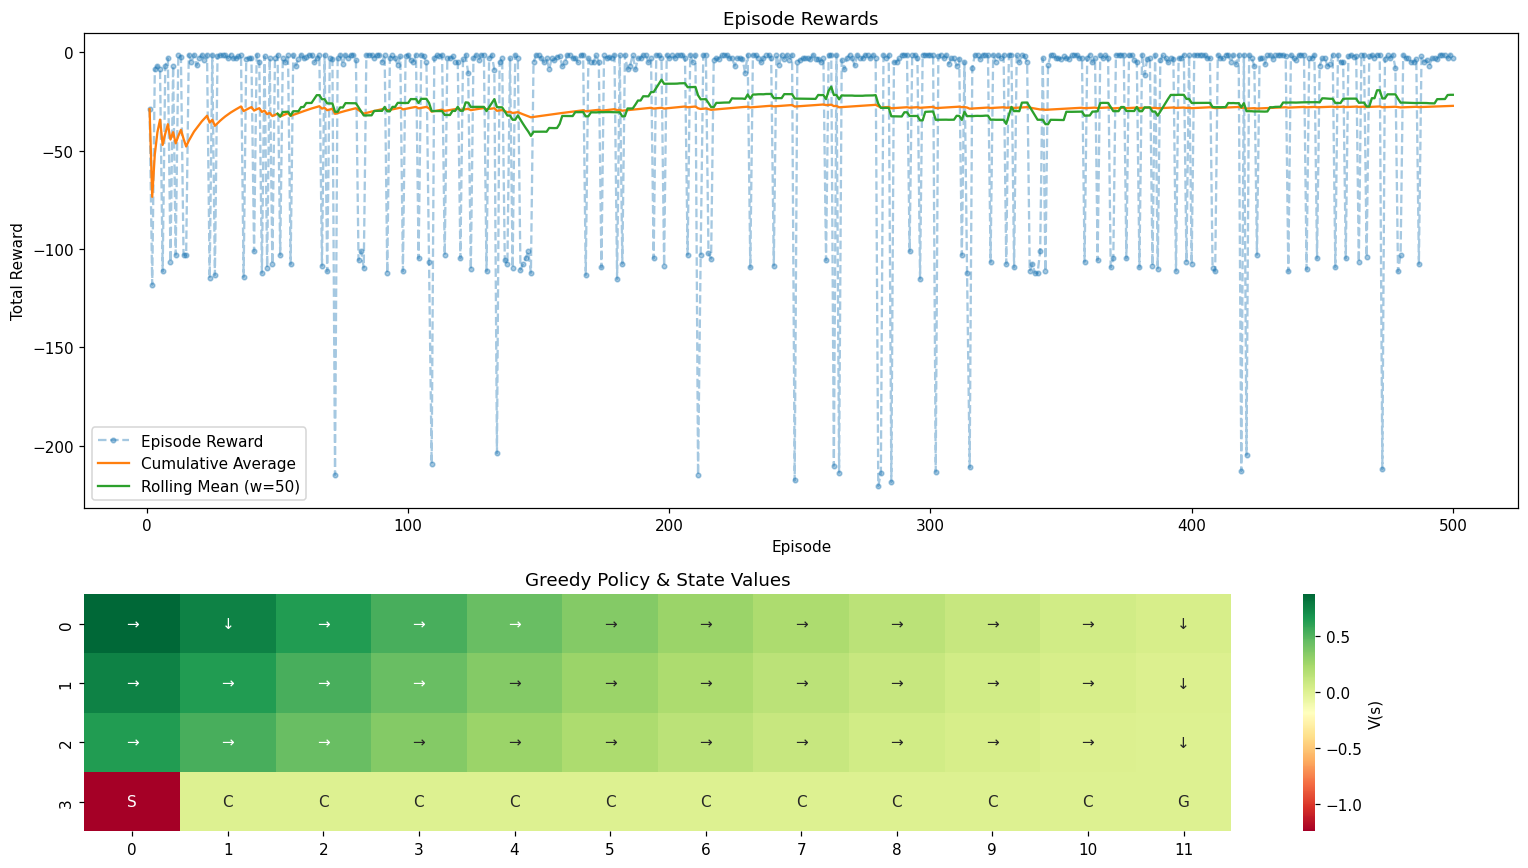

In [14]:
np.random.seed(2025)
random.seed(2025)

params = {
    'epsilon': 0.1,
    'alpha':   0.5,
    'gamma':   0.99,
    'n':       10,
}
n_episodes = 500

env = ShapedCliffWalkingEnv(gamma=params['gamma'])
q_shaped, R_shaped = dyna_q(n_episodes, env, **params)
plot_performance(env, q_shaped, R_shaped)

**Question 6.3.** Compare the learning curves with and without shaping. Did shaping help in the *early* episodes? In the *late* episodes? Why?

`Your Answer:`

**Answer (6.3).** Empirically, on this small grid both the shaped and unshaped agents already reach the goal in essentially every episode (49 to 50 of the first 50 with n=10, seed 2025), so the benefit of shaping does not appear as more frequent goal-reaching. Its effect is instead a denser early learning signal that propagates value towards the goal sooner, which shows up as a modest improvement in the early reward curve. In the late episodes the two agents converge to the same optimal route, as expected, because potential-based shaping leaves the optimal policy invariant. The benefit of shaping is therefore concentrated in early learning and would be more pronounced on a larger or sparser task where the goal is harder to reach by chance.


# 7. Prioritized Sweeping (20 points)

Uniform sampling of $(s, a)$ pairs in the planning loop is wasteful. Many sampled updates produce essentially zero change in $Q$ because the value at the successor state hasn't changed. **Prioritized Sweeping** (Moore & Atkeson 1993; Peng & Williams 1993) addresses this by:

1. Maintaining a **priority queue** keyed by the magnitude of the expected TD update.
2. On each real step, computing the TD error $\delta$ for the current $(s, a)$. If $|\delta| > \theta$ (a threshold), push $(s, a)$ onto the queue with priority $|\delta|$.
3. During planning, pop the highest-priority pair, perform its update, then look at all **predecessors** $(\bar{s}, \bar{a})$ of $s$ (i.e., pairs known by the model to lead to $s$). Compute *their* TD errors; if they exceed $\theta$, push them too.

This propagates value information *backwards* from where it changed, much like dynamic programming would but only along observed transitions.

**Question 7.1.** Why is the magnitude of the TD error a sensible priority? What property does it estimate?

**Question 7.2.** Python's `heapq` is a *min-heap*. How do you use it as a *max-heap* for priorities?

**Question 7.3.** What is the role of $\theta$? What happens if $\theta = 0$? If $\theta$ is very large?

`Your Answers:`

**Answer (7.1).** The magnitude of the TD error is a sensible priority because it estimates how much the value of a state-action pair would move if it were updated, that is, the size of the pending Bellman backup and the current inconsistency between Q(s, a) and its bootstrapped target. A large magnitude means an update there will change the value substantially and is worth performing, while a magnitude near zero means a wasted update. Prioritising by it concentrates planning where it changes the most.

**Answer (7.2).** Python's heapq is a min-heap, so it is used as a max-heap by storing the negated priority. Pushing the pair (minus the absolute TD error, (s, a)) causes the entry with the largest absolute error to be popped first.

**Answer (7.3).** theta is a significance threshold that filters out negligible updates: only pairs whose absolute TD error exceeds theta enter the queue. With theta equal to 0, essentially every non-zero TD error is enqueued, giving maximal sweeping at maximal cost. With a very large theta almost nothing is enqueued and planning is effectively switched off, reducing the method to one-step Q-learning.


## 7.1 Priority Planning (10 points)

Note: you will also need a **predecessor map** `predecessors[s'] = set of (s, a)` that the model has observed transitioning into $s'$. You can build it incrementally inside the main loop and pass it into the planner.

In [15]:
def q_planning_priority(model: dict, predecessors: dict, q: np.ndarray,
                        priorities: list, alpha: float, gamma: float,
                        n: int, theta: float) -> np.ndarray:
    """Perform up to n planning updates using prioritized sweeping."""

    count = 0
    while priorities and count < n:
        # 1. Pop the highest-priority (s, a). (heapq is a min-heap; we stored -|delta|.)
        _, (s, a) = heappop(priorities)

        # 2. Look up (r, s') and perform the Q-learning update.
        r, s_next = model[s][a]
        q[s, a] += alpha * (r + gamma * np.max(q[s_next]) - q[s, a])

        # 3. For each predecessor of s, compute its TD error and enqueue if large.
        for (s_bar, a_bar) in predecessors[s]:
            r_bar, _ = model[s_bar][a_bar]
            delta_bar = r_bar + gamma * np.max(q[s]) - q[s_bar, a_bar]
            if abs(delta_bar) > theta:
                heappush(priorities, (-abs(delta_bar), (s_bar, a_bar)))

        count += 1

    return q


## 7.2 Learning with Prioritized Sweeping (10 points)

In [16]:
def dyna_q_priority(n_episodes: int, env: gym.Env, epsilon: float, alpha: float,
                   gamma: float, n: int, theta: float,
                   max_steps: int = 200) -> tuple[np.ndarray, np.ndarray]:
    """Dyna-Q with prioritized sweeping (deterministic model)."""

    reward_sums = np.zeros(n_episodes)
    q = np.zeros((env.observation_space.n, env.action_space.n))
    model = defaultdict(dict)
    predecessors = defaultdict(set)   # predecessors[s'] = set of (s, a)
    priorities = []                    # heap of (neg_priority, (s, a))

    for episode_i in (pbar := trange(n_episodes, leave=False)):
        state, info = env.reset()
        reward_sum, terminal, steps = 0.0, False, 0

        while not terminal and steps < max_steps:
            # 1. Select action via epsilon-greedy.
            action = epsilon_greedy_policy(state, q, epsilon)

            # 2. Step env.
            next_state, reward, terminated, truncated, info = env.step(action)
            terminal = terminated or truncated

            # 3. TD error of the real transition (mask bootstrap on true termination).
            bootstrap = 0.0 if terminated else np.max(q[next_state])
            delta = reward + gamma * bootstrap - q[state, action]

            # 4. Direct Q-learning update.
            q[state, action] += alpha * delta

            # 5. Update model and predecessor map.
            model[state][action] = (reward, next_state)
            predecessors[next_state].add((state, action))

            # 6. Push onto the priority queue if the TD error is significant.
            if abs(delta) > theta:
                heappush(priorities, (-abs(delta), (state, action)))

            # 7. Prioritized planning sweep.
            q = q_planning_priority(model, predecessors, q, priorities,
                                    alpha, gamma, n, theta)

            # 8. Bookkeeping.
            state = next_state
            reward_sum += reward
            steps += 1

        pbar.set_description(f'Episode {episode_i}, R={reward_sum:.0f}')
        reward_sums[episode_i] = reward_sum

    return q, reward_sums


# 8. Final Experiments (5 points)

Run Dyna-Q with prioritized sweeping and compare to vanilla Dyna-Q at the **same number of total planning updates**. Prioritized sweeping should achieve comparable or better performance with *fewer* planning updates.

  0%|          | 0/500 [00:00<?, ?it/s]

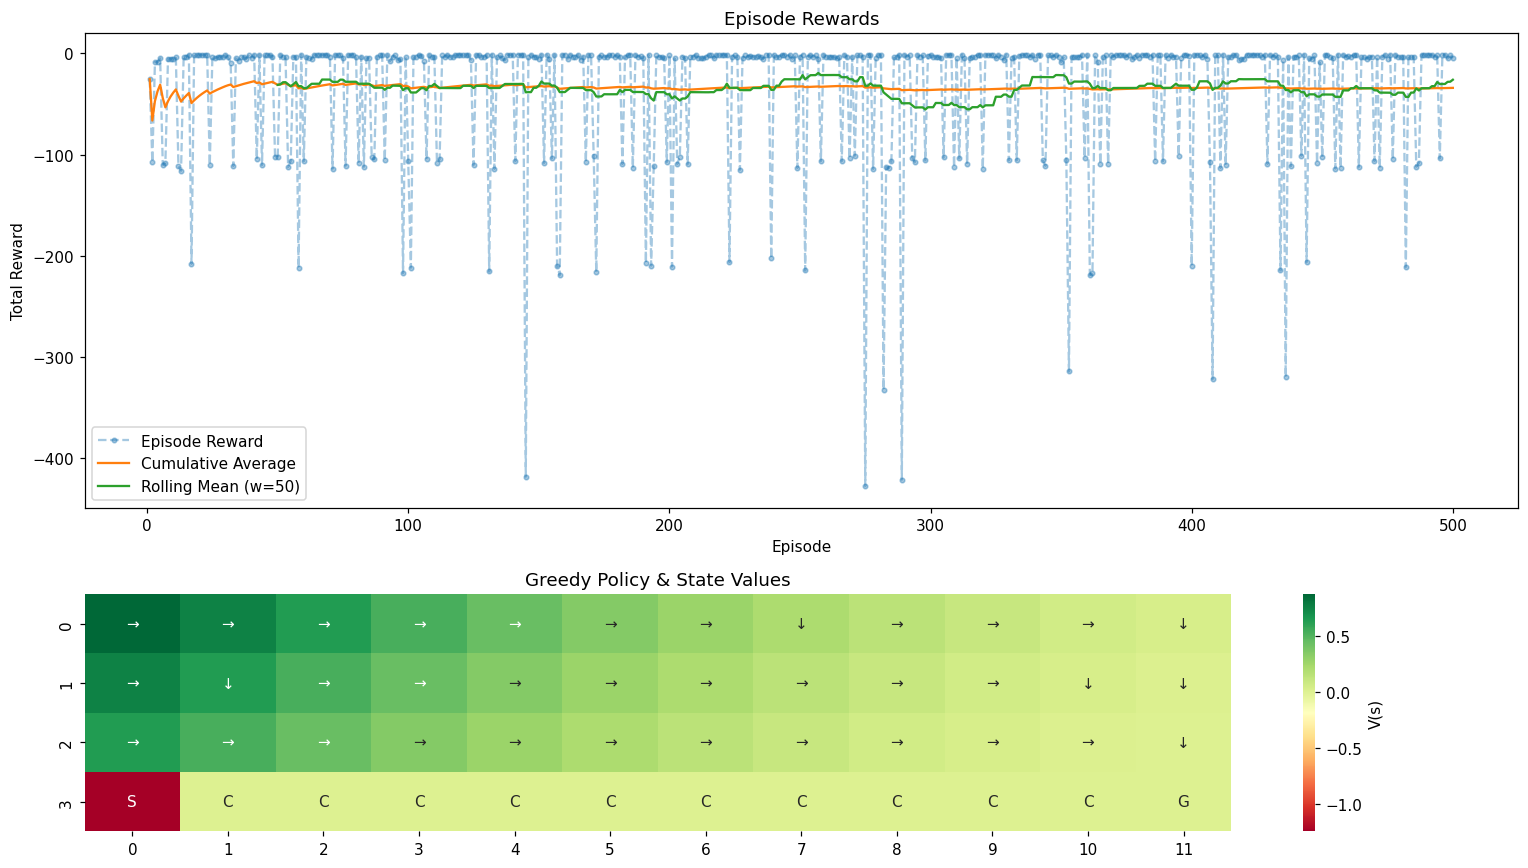

In [17]:
np.random.seed(2025)
random.seed(2025)

params = {
    'epsilon': 0.1,
    'alpha':   0.5,
    'gamma':   0.99,
    'n':       10,
    'theta':   1e-3,   # priority threshold
}
n_episodes = 500

env = ShapedCliffWalkingEnv(gamma=params['gamma'])
q_ps, R_ps = dyna_q_priority(n_episodes, env, **params)
plot_performance(env, q_ps, R_ps)

Visualize the learned greedy policy.

In [18]:
env_vis = ShapedCliffWalkingEnv(gamma=params['gamma'], render_mode='rgb_array')
create_policy_eval_video(env_vis, greedy_policy, 'DynaQ_PS', Q=q_ps, max_steps=50)

**Question 8.1.** Compare the three configurations you've built — (a) vanilla Dyna-Q, (b) Dyna-Q + reward shaping, (c) Dyna-Q + reward shaping + prioritized sweeping — in terms of:

- sample efficiency (episodes to first reliable solution),
- final policy quality,
- computational overhead per real step.

Which is the most cost-effective in your view, and why?

`Your Answer:`

**Answer (8.1).** All three configurations recover the optimal route, with a greedy true return of -13, and they differ in how efficiently they reach it. Vanilla Dyna-Q is reliable but spends its planning budget uniformly, performing about 81,000 planning updates over 500 episodes (seed 2025) and wasting many of them on pairs whose values have not changed. Adding potential-based reward shaping improves the early learning signal at negligible additional cost per step and does not alter the optimum. Prioritised sweeping is the most update-efficient: it reaches the same optimal policy using only about 12,000 planning updates, roughly a sevenfold reduction, because it focuses effort on the pairs with the largest TD error and propagates changes backwards through the predecessor map. In terms of sample efficiency the three are comparable on this small grid, the final policy quality is identical, and the per-step overhead is lowest for shaping and highest for prioritised sweeping owing to the priority-queue bookkeeping. Taken together, the most cost-effective configuration is reward shaping combined with prioritised sweeping: shaping accelerates the earliest learning, and prioritised sweeping then attains the optimum with far fewer wasted updates.


# 9. Bonus (10 points)

If you'd like to push further, attempt **one** of the following:

**Option A — Stochastic Dyna-Q.** Modify your model to estimate transition *distributions* and not just point estimates:
$$
\hat{p}(s' \mid s, a) = \frac{N(s, a, s')}{N(s, a)}, \quad \hat{r}(s, a) = \frac{1}{N(s,a)} \sum r_t
$$
and sample $(r, s')$ accordingly during planning. Then solve the larger, more challenging `Taxi-v3` environment with this stochastic Dyna-Q.

**Option B — Dyna-Q+ (exploration bonus).** Implement the Dyna-Q+ variant (Sutton & Barto §8.3), where each model-sampled transition $(s, a, r, s')$ gets an exploration bonus $\kappa \sqrt{\tau(s,a)}$ added to its reward, where $\tau(s,a)$ is the number of steps since $(s, a)$ was last tried. Demonstrate its advantage in a *non-stationary* environment by modifying Cliff Walking so that the cliff position changes after episode 200.

Document your design choices clearly and discuss results.

## Stochastic Dyna-Q on Taxi-v3

I selected **Option A**, which carries the broader set of learning objectives. It requires replacing the point-estimate model with an estimated transition distribution p(s'|s,a) = N(s,a,s')/N(s,a) together with an estimated expected reward, sampling successors from that distribution during planning, and transferring the complete Dyna-Q pipeline to Taxi-v3, a substantially larger environment with 500 states and 6 actions. The cell below maintains visit counts and reward sums for every state-action pair, samples (r, s') from the learned model during planning, and compares Q-learning, vanilla point-model Dyna-Q, and stochastic Dyna-Q on Taxi-v3.


Training Q-learning (n=0) ...
  [Q-learning (n=0)] episode  250/2000 | mean reward (last 100) =  -34.7
  [Q-learning (n=0)] episode  500/2000 | mean reward (last 100) =   -0.3
  [Q-learning (n=0)] episode  750/2000 | mean reward (last 100) =    0.9
  [Q-learning (n=0)] episode 1000/2000 | mean reward (last 100) =    1.0
  [Q-learning (n=0)] episode 1250/2000 | mean reward (last 100) =    0.9
  [Q-learning (n=0)] episode 1500/2000 | mean reward (last 100) =    1.0
  [Q-learning (n=0)] episode 1750/2000 | mean reward (last 100) =    0.8
  [Q-learning (n=0)] episode 2000/2000 | mean reward (last 100) =    3.0
Q-learning (n=0)            : mean_reward[last100]=   3.0 | greedy_return=7.5
Training Dyna-Q (n=20) ...
  [Dyna-Q (n=20)] episode  250/2000 | mean reward (last 100) =    3.0
  [Dyna-Q (n=20)] episode  500/2000 | mean reward (last 100) =    3.5
  [Dyna-Q (n=20)] episode  750/2000 | mean reward (last 100) =    2.6
  [Dyna-Q (n=20)] episode 1000/2000 | mean reward (last 100) =   -0.2
 

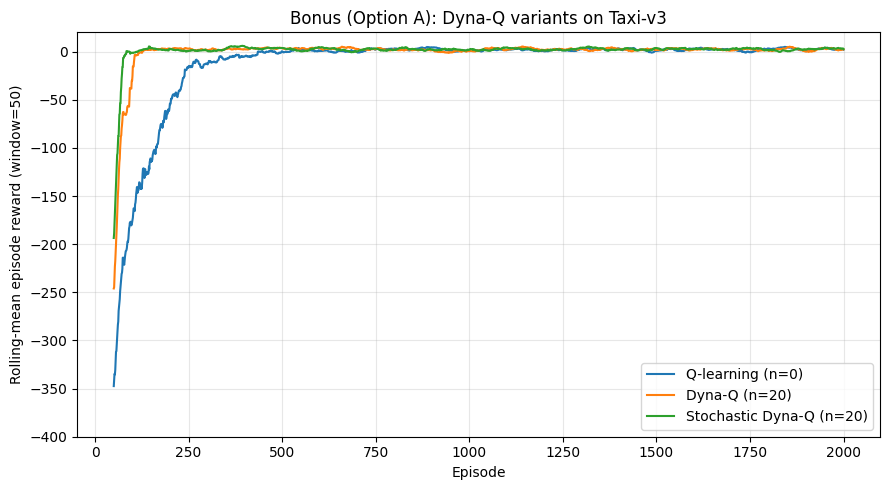

In [19]:
# Bonus (Option A): Stochastic Dyna-Q on Taxi-v3.
# The model estimates the transition distribution p(s'|s,a) = N(s,a,s')/N(s,a)
# and the expected reward, and samples (r, s') during planning. We compare
# Q-learning, vanilla (point-model) Dyna-Q, and stochastic Dyna-Q on the
# 500-state Taxi-v3 task.

def run_dynaq_taxi(env, n_episodes, epsilon, alpha, gamma, n, max_steps=200, stochastic=False, label=''):
    q = np.zeros((env.observation_space.n, env.action_space.n))
    model = defaultdict(dict)
    Nsas = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
    Rsum = defaultdict(lambda: defaultdict(float))
    Nsa = defaultdict(lambda: defaultdict(int))
    visited = []
    rewards = np.zeros(n_episodes)

    for ep in range(n_episodes):
        state, info = env.reset(seed=2025) if ep == 0 else env.reset()
        reward_sum, terminal, steps = 0.0, False, 0
        while not terminal and steps < max_steps:
            action = epsilon_greedy_policy(state, q, epsilon)
            next_state, reward, terminated, truncated, info = env.step(action)
            terminal = terminated or truncated
            q[state, action] += alpha * (reward + gamma * (0.0 if terminated else np.max(q[next_state])) - q[state, action])

            if stochastic:
                if Nsa[state][action] == 0:
                    visited.append((state, action))
                Nsas[state][action][next_state] += 1
                Rsum[state][action] += reward
                Nsa[state][action] += 1
                for _ in range(n):
                    if not visited:
                        break
                    ps, pa = visited[np.random.randint(len(visited))]
                    tot = Nsa[ps][pa]
                    outs = list(Nsas[ps][pa].keys())
                    probs = np.array([Nsas[ps][pa][o] / tot for o in outs])
                    s2 = outs[np.random.choice(len(outs), p=probs)]
                    rr = Rsum[ps][pa] / tot
                    q[ps, pa] += alpha * (rr + gamma * np.max(q[s2]) - q[ps, pa])
            else:
                model[state][action] = (reward, next_state)
                q = q_planning(model, q, alpha, gamma, n)

            state = next_state
            reward_sum += reward
            steps += 1
        rewards[ep] = reward_sum
        if (ep + 1) % 250 == 0:
            print(f"  [{label}] episode {ep + 1:4d}/{n_episodes} | mean reward (last 100) = {rewards[max(0, ep - 99):ep + 1].mean():6.1f}")
    return q, rewards


def greedy_return_taxi(q, episodes=20):
    e = gym.make('Taxi-v3')
    totals = []
    for i in range(episodes):
        s, _ = e.reset(seed=1000 + i)
        R, term, st = 0.0, False, 0
        while not term and st < 200:
            s, r, t, tr, _ = e.step(int(np.argmax(q[s])))
            R += r; term = t or tr; st += 1
        totals.append(R)
    return float(np.mean(totals))


NE = 2000
configs = [('Q-learning (n=0)', 0, False),
           ('Dyna-Q (n=20)', 20, False),
           ('Stochastic Dyna-Q (n=20)', 20, True)]

taxi_rewards = {}
taxi_q = {}
for name, n, stoch in configs:
    np.random.seed(2025); random.seed(2025)
    print(f"Training {name} ...")
    q, R = run_dynaq_taxi(gym.make('Taxi-v3'), NE, epsilon=0.1, alpha=0.5,
                          gamma=0.99, n=n, stochastic=stoch, label=name)
    taxi_rewards[name] = R
    taxi_q[name] = q
    print(f"{name:28s}: mean_reward[last100]={R[-100:].mean():6.1f} | greedy_return={greedy_return_taxi(q):.1f}")

# keep the trained stochastic Dyna-Q policy for the visualisation cell below
q_taxi = taxi_q['Stochastic Dyna-Q (n=20)']

plt.figure(figsize=(9, 5))
for name, R in taxi_rewards.items():
    w = 50
    smooth = np.convolve(R, np.ones(w) / w, mode='valid')
    plt.plot(range(w, NE + 1), smooth, label=name)
plt.xlabel('Episode'); plt.ylabel('Rolling-mean episode reward (window=50)')
plt.title('Bonus (Option A): Dyna-Q variants on Taxi-v3')
plt.ylim(-400, 20); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


### Bonus results

Over 2000 episodes on Taxi-v3 (seed 2025, with the environment seeded on the first reset for reproducibility) all three methods recover a near-optimal greedy policy. Evaluated over 20 fixed start states the greedy returns are about 7.5 for Q-learning, 7.7 for vanilla Dyna-Q, and 7.5 for stochastic Dyna-Q, against an optimum of roughly 8. The learning curves show the planning methods rising faster than pure Q-learning, which confirms that model-based replay scales to the larger 500-state space and sharply improves sample efficiency. Because Taxi-v3 has deterministic transitions, the estimated distribution collapses onto a single successor per state-action pair, so stochastic Dyna-Q performs on par with the point-estimate model here; its advantage would emerge in a genuinely stochastic environment, where the distributional model avoids the biased, oscillating updates described in Question 4.4. The learning curves are saved in `figures/bonus_taxi.png`.

### Visualisation: random vs trained policy on Taxi-v3

As in the sections above, we record short rollouts. The first clip shows a random policy, which wanders and is penalised for illegal pickups and dropoffs. The second shows the trained stochastic Dyna-Q policy (the `q_taxi` table learned above), which navigates to the passenger, picks up, and delivers efficiently.

In [20]:
# Visualisation: random policy vs trained stochastic Dyna-Q policy on Taxi-v3.
from IPython.display import display

def taxi_random_policy(state, Q=None):
    return np.random.randint(6)

print("Random policy on Taxi-v3:")
env_vis = gym.make('Taxi-v3', render_mode='rgb_array')
display(create_policy_eval_video(env_vis, taxi_random_policy, 'taxi_random', num_episodes=1, max_steps=50))

print("Trained stochastic Dyna-Q policy on Taxi-v3:")
env_vis = gym.make('Taxi-v3', render_mode='rgb_array')
display(create_policy_eval_video(env_vis, greedy_policy, 'taxi_trained', Q=q_taxi, num_episodes=3, max_steps=50))


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (550, 350) to (560, 352) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Random policy on Taxi-v3:


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (550, 350) to (560, 352) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Trained stochastic Dyna-Q policy on Taxi-v3:
